# BatteryMat × AtomGPT — pipeline demo + `battery_predict` LLM tool

This notebook has two halves:

1. **BatteryMat pipeline** ([jae-hlee/batterymat_jae](https://github.com/jae-hlee/batterymat_jae)) — high-throughput battery-electrode screening with ALIGNN force-fields + JARVIS-DFT. We run jae's actual voltage method live on a structure, load the real pre-computed screening results, and generate real VASP DFT inputs.
2. **`battery_predict` LLM tool** (`agapi`) — the *served* version that POSTs to `atomgpt.org/battery/predict`, shown both as a raw function call and via the AtomGPT chat agent.

Runs on a free Colab CPU runtime. The actual VASP/DFT and NEB runs require a cluster and are not executed here.

## Section A — Setup

In [ ]:
# agapi is installed from the `add-battery-predict` branch (the one that contains battery_predict).
!pip -q install "git+https://github.com/redbbean/agapi.git@add-battery-predict"
!pip -q install jarvis-tools alignn matplotlib pandas bokeh
# jae's repo ships a setup.py, so install it editable (its documented usage) — also makes the
# `batterymat_jae` package importable for the ptable.py cell below.
!git clone -q https://github.com/jae-hlee/batterymat_jae.git
!pip -q install -e ./batterymat_jae

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 843.0/843.0 kB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.4/142.4 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.4/170.4 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.5/962.5 kB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 73.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338.3/338.3 kB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 kB 5.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.7/17.7 MB 72.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 474.0/474.0 kB 28.8 MB/s eta 0:00:00


In [ ]:
# ==== DGL setup for ALIGNN-FF (used in B1) ====
# Root cause of the earlier import errors: `import dgl` eagerly imports DGL's GraphBolt
# submodule, which needs old torchdata APIs (datapipes / dataloader2) that torch 2.11 removed.
# ALIGNN-FF uses only DGL core (AvgPooling), never GraphBolt — so block GraphBolt from
# importing instead of chasing each missing torchdata module.
# NOTE: run this BEFORE `alignn` is first imported. If you already imported alignn this
# session (e.g. ran B1), do Runtime > Restart, then run top-to-bottom.
import sys, types, torch
_tv = torch.__version__.split("+")[0]
_torch_mm = ".".join(_tv.split(".")[:2])
_dev = f"cu{torch.version.cuda.replace('.', '')}" if torch.version.cuda else "cpu"
_url = f"https://data.dgl.ai/wheels/torch-{_torch_mm}/{_dev}/repo.html"
print("torch", _tv, "| installing dgl from", _url)
!pip -q install dgl -f {_url}

def _block_graphbolt():
    for _m in [x for x in sys.modules if x == "dgl" or x.startswith("dgl.")]:
        del sys.modules[_m]
    gb = types.ModuleType("dgl.graphbolt")
    gb.__path__ = []                      # behave as a package
    gb.__getattr__ = lambda name: None    # any GraphBolt symbol -> None (unused)
    sys.modules["dgl.graphbolt"] = gb

# Attempt 1 (root-cause fix): block GraphBolt entirely.
_block_graphbolt()
try:
    import dgl
    from dgl.nn import AvgPooling
    assert callable(AvgPooling)
    print("loaded dgl via graphbolt-block")
except Exception as e:
    # Attempt 2 (fallback): restore the old torchdata APIs GraphBolt expects.
    print("graphbolt-block failed:", repr(e), "-> trying torchdata==0.7.1")
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--no-deps",
                    "torchdata==0.7.1"], check=False)
    for _m in [x for x in sys.modules
               if x == "dgl" or x.startswith("dgl.") or x.startswith("torchdata")]:
        del sys.modules[_m]
    import dgl
    from dgl.nn import AvgPooling

# ---- sharp pass/fail signal (our test for this bug) ----
assert callable(AvgPooling), "FAIL: DGL core not usable (AvgPooling is not callable)"
print("PASS: dgl", dgl.__version__, "| AvgPooling OK -> B1 ready")

torch 2.11.0 | installing dgl from https://data.dgl.ai/wheels/torch-2.11/cpu/repo.html
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 44.9 MB/s eta 0:00:00


DGL backend not selected or invalid.  Assuming PyTorch for now.


Setting the default backend to "pytorch". You can change it in the ~/.dgl/config.json file or export the DGLBACKEND environment variable.  Valid options are: pytorch, mxnet, tensorflow (all lowercase)
loaded dgl via graphbolt-block
PASS: dgl 2.1.0 | AvgPooling OK -> B1 ready


In [ ]:
import os, getpass
os.environ["AGAPI_KEY"] = getpass.getpass("AtomGPT (AGAPI) API key: ")
API_KEY = os.environ["AGAPI_KEY"]

AtomGPT (AGAPI) API key: ··········


In [ ]:
LICOO2 = """\
LiO2Co
1.0
2.719 -0.003 4.091
1.234 2.423 4.091
-0.004 -0.003 4.913
Li Co O
1 1 2
Cartesian
1.974 1.209 6.548
0.0 0.0 0.0
1.027 0.629 3.405
2.922 1.789 9.690
"""

import matplotlib.pyplot as plt
import pandas as pd

# Cloned repo layout is batterymat_jae/ (repo) -> batterymat_jae/ (package)
BASE = "batterymat_jae/batterymat_jae"
print("LiCoO2 POSCAR + constants ready")

LiCoO2 POSCAR + constants ready


### B1 — Live (tiny): voltage profile via jae's actual `get_voltage_profile`

This runs **jae's real Stage-1 method** — `atom_to_energy` + `get_voltage_profile` from `screening_anode/screen.py` — on LiCoO₂: it removes the Li with ALIGNN-FF and computes the voltage from energy differences (`E_delithiated − E_lithiated − unary_energy(Li)`).

> The code is **copied verbatim** from `screen.py` rather than imported: importing that module runs its entire JARVIS-dataset screening loop (no `__main__` guard) and would hang Colab. Same functions, same `wt01` ALIGNN-FF model, just applied to one structure. First call downloads the ALIGNN-FF weights and is slow.

> **Needs DGL** (installed in Section A). If this errors with `AvgPooling ... 'NoneType' object is not callable`, DGL wasn't present when `alignn` first imported — do **Runtime → Restart**, then run the notebook top-to-bottom.

> **This is the fast ML *pre-screen*, not an accurate cell voltage.** It does single-point energies (no per-frame relaxation) and uses screen.py's coarse `unary_energy(Li)` reference (~−0.925 eV). The accurate voltage comes from the DFT workflow (Stage 3, B4 →), which relaxes each frame and uses the corrected `e_li_metal = −1.9031 eV` plus a convex-hull construction — `dft_prep.py` notes the old Li reference "was wrong by ~1 eV." Expect B1's number to differ from the DFT/served values.

In [ ]:
# --- copied verbatim from batterymat_jae/screening_anode/screen.py ---
from jarvis.core.atoms import Atoms
from jarvis.analysis.thermodynamics.energetics import unary_energy
from jarvis.core.specie import Specie
from jarvis.io.vasp.inputs import Poscar
from alignn.ff.ff import AlignnAtomwiseCalculator, wt01_path

calculator = AlignnAtomwiseCalculator(path=wt01_path(), stress_wt=0.3)


def atom_to_energy(atoms):
    atoms = atoms.ase_converter()
    atoms.calc = calculator
    atoms.get_forces()
    return atoms.get_potential_energy()


def get_voltage_profile(atoms=[], element="Li", charge=None):
    if charge is None:
        charge = abs(Specie(element).element_property("min_oxid_s"))
    elements = atoms.elements
    coords = atoms.frac_coords
    lattice_mat = atoms.lattice_mat
    options = [ii for ii, i in enumerate(elements) if i == element]
    comb = [options[0:i + 1] for i in range(len(options))]
    mem = [{"atoms": atoms, "comb": [], "en": atom_to_energy(atoms)}]
    for i in comb:
        new_elements, new_coords = [], []
        for jj, j in enumerate(elements):
            if jj not in i:
                new_elements.append(j)
                new_coords.append(coords[jj])
        new_atoms = Atoms(coords=new_coords, lattice_mat=lattice_mat,
                          elements=new_elements, cartesian=False)
        mem.append({"en": atom_to_energy(new_atoms), "atoms": new_atoms, "comb": i})
    voltages = []
    for ii in range(len(mem) - 1):
        voltages.append(mem[ii + 1]["en"] - mem[ii]["en"] - unary_energy(element))
    return voltages
# --- end verbatim ---

atoms = Poscar.from_string(LICOO2).atoms
voltages = get_voltage_profile(atoms=atoms, element="Li")
print("LiCoO2 Li-removal voltage(s) [V]:", voltages)

dir_path /root/.cache/atomgptlab/alignn_ff/alignnff_wt01


100%|██████████| 15.0M/15.0M [00:01<00:00, 12.8MiB/s]
/usr/local/lib/python3.12/dist-packages/alignn/ff/calculators.py:317: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  torch.tensor(atoms.cell)


LiCoO2 Li-removal voltage(s) [V]: [5.739703941345215]


### B2 — Real results (canned): screening + cathode ranking CSVs

In [ ]:
li = pd.read_csv(f"{BASE}/screening_anode/Li.csv")
print("Li anode-screening candidates:", li.shape)
li.head()

Li anode-screening candidates: (7193, 5)


,Unnamed: 0,jid,formula,voltages,max_voltages
0,0,JVASP-97915,Ba14Na14LiN6,[2.819833087921142],2.819833
1,1,JVASP-42300,Li4Mn3Cr3O12,"[4.494368362426758, 4.436521339416504, 4.82434...",5.772729
2,2,JVASP-86436,LiSbF6,[7.323087978363037],7.323088
3,3,JVASP-48166,LiMn5O3F5,[4.307984161376953],4.307984
4,4,JVASP-64377,Ba4LiHf,[2.773178029060363],2.773178


In [ ]:
cath = pd.read_csv(f"{BASE}/screening_cathode/cathode_candidates_ranked.csv")
cols = ["formula", "jid", "avg_voltage", "max_voltage", "max_grav_cap", "score"]
cath[cols].head(10)

,formula,jid,avg_voltage,max_voltage,max_grav_cap,score
0,LiCr2P2O8,JVASP-117419,4.419557,5.089778,22.661638,0.325687
1,Rb2LiFeF6,JVASP-141543,4.079221,4.217412,38.928310,0.315696
2,Li3FeO3,JVASP-117295,4.393623,5.469795,21.388835,0.310562
3,LiV2F7,JVASP-116849,4.187010,4.772046,28.318555,0.296559
4,Rb2LiFeF6,JVASP-154749,4.253186,4.460853,38.928310,0.285105
5,Li2MgMn3O8,JVASP-96563,4.230054,4.385232,21.014204,0.276384
6,LiCoH24C8N8O12,JVASP-95533,4.104531,4.271872,27.532397,0.274818
7,LiH4SNO4,JVASP-97428,4.010995,4.188935,29.139980,0.260374
8,Na2LiB5P2O14,JVASP-96441,3.845822,5.482659,37.387329,0.256967
9,Li4Co3O7,JVASP-112912,4.203819,5.106929,23.062526,0.256318


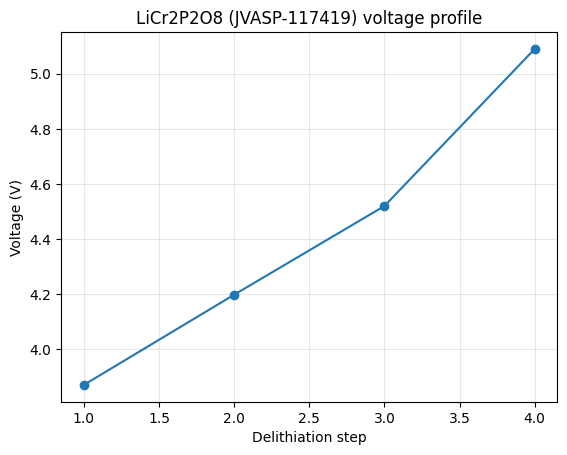

In [ ]:
# Plot the voltage profile of the top-ranked cathode candidate.
row = cath.iloc[0]
vp = [float(x) for x in str(row["voltage_profile"]).split(";")]
plt.plot(range(1, len(vp) + 1), vp, "o-")
plt.xlabel("Delithiation step"); plt.ylabel("Voltage (V)")
plt.title(f"{row['formula']} ({row['jid']}) voltage profile")
plt.grid(alpha=0.3); plt.show()

### B3 — Periodic-table trend (jae's `ptable.py`)

Mean max-voltage per element across the ranked cathode candidates.

In [ ]:
import sys
# The cloned repo root (./batterymat_jae) shares the inner package's name and shadows it
# on sys.path, so import the subpackage directly from the package dir (BASE).
sys.path.insert(0, BASE)  # BASE = batterymat_jae/batterymat_jae
import periodic_trend.ptable as ptable
from periodic_trend.ptable import aggregate_by_element
from bokeh.io import output_notebook

elems, vals = aggregate_by_element(
    f"{BASE}/screening_cathode/cathode_candidates_ranked.csv",
    prop="max_voltage", agg="mean",
)

output_notebook()
# plot_ptable_trend() internally calls output_file()+save(), which forces HTML-file output and
# binds the figure to a document — so calling show() on it afterwards raises "Models must be
# owned by only a single document". Fix: neutralize its output_file (keep "notebook" output)
# and pass save_plot=False so it show()s the figure once -> renders inline, single attach.
_orig_output_file = ptable.output_file
ptable.output_file = lambda *a, **k: None
try:
    ptable.plot_ptable_trend(data_elements=elems, data_list=vals, save_plot=False)
finally:
    ptable.output_file = _orig_output_file

> Note: we import `periodic_trend.ptable` after adding the package dir to `sys.path` — the cloned repo folder shares the package's name and would otherwise shadow it. `screening_anode/screen.py` is avoided entirely because it runs the full screening on import (see B1).

### B4 — DFT input generation (`dft_prep.py init`, no dataset download)

Stage 3 prepares VASP inputs for sequential supercell delithiation. We call jae's actual `generate_sequential_init()` (the `init` command), but hand it a **one-row DataFrame** built from our LiCoO₂ structure via its `dft3d_df=` argument — so it uses our structure instead of downloading the full JARVIS `dft_3d` set. It writes a real **POSCAR / INCAR / KPOINTS / POTCAR_spec** for the `step_00` relaxation (the `POTCAR_spec` lists recommended PAW labels; actual pseudopotentials are user-supplied at run time). No ALIGNN/GPU needed — `init` only writes inputs.

> This is just the **first** step of the workflow. The full loop — `next` (ALIGNN-ranked Li removal from each relaxed CONTCAR) → `record` energies → `voltage` (convex-hull curve with `e_li_metal`) — requires actually running VASP on each step, so it can't complete in Colab.

In [ ]:
import sys
from pathlib import Path
sys.path.insert(0, BASE)
from screening_cathode.dft_prep import generate_sequential_init
from jarvis.io.vasp.inputs import Poscar

atoms = Poscar.from_string(LICOO2).atoms
# One-row dataframe so init uses OUR structure instead of downloading JARVIS dft_3d.
demo_df = pd.DataFrame([{
    "jid": "LiCoO2-demo",
    "atoms": atoms.to_dict(),
    "spg_number": 166,  # R-3m -> layered -> optB88-vdW branch
}])
sup_dir = generate_sequential_init("LiCoO2-demo", dft3d_df=demo_df, output_dir="dft_demo")
print("supercell dir:", sup_dir)

LiCoO2-demo: supercell 2x2x2 (32 atoms, 8 Li)
  Functional: optb88vdw
  Lattice: 9.82, 9.82, 9.83 Å
  KPOINTS: 2 2 2
  -> dft_demo/LiCoO2-demo/supercell_2x2x2/step_00_Li8
supercell dir: dft_demo/LiCoO2-demo/supercell_2x2x2


In [ ]:
step_dir = next(p for p in Path(sup_dir).iterdir() if p.name.startswith("step_"))
print("generated files:", sorted(p.name for p in step_dir.iterdir()))
for fn in ["POSCAR", "INCAR", "KPOINTS", "POTCAR_spec"]:
    print(f"\n===== {fn} =====")
    print((step_dir / fn).read_text())

generated files: ['INCAR', 'KPOINTS', 'POSCAR', 'POTCAR_spec']

===== POSCAR =====
System
1.0
5.438 -0.006 8.182
2.468 4.846 8.182
-0.008 -0.006 9.826
Li Co O 
8 8 16 
direct
0.24986137888785448 0.2501031058655898 0.25008045855356387 Li
0.24986137888785442 0.25010310586558987 0.7500804585535639 Li
0.24986137888785448 0.7501031058655898 0.2500804585535638 Li
0.24986137888785442 0.7501031058655897 0.750080458553564 Li
0.7498613788878543 0.25010310586558987 0.2500804585535638 Li
0.7498613788878544 0.2501031058655898 0.750080458553564 Li
0.7498613788878543 0.7501031058655898 0.25008045855356387 Li
0.7498613788878544 0.7501031058655897 0.7500804585535638 Li
0.0 0.0 0.0 Co
4.972920543755131e-20 3.567287999538819e-20 0.5 Co
1.687419431312552e-17 0.4999999999999999 5.625609431847998e-18 Co
2.6926364666276987e-17 0.4999999999999999 0.5000000000000001 Co
0.49999999999999994 2.6754659996541143e-20 6.113676066310582e-17 Co
0.4999999999999999 2.8266523308573872e-19 0.5000000000000001 Co
0.499999999

### B5 — Real DFT voltage curve (convex hull) — offline, from committed energies

This is the pipeline's **headline output**. The repo ships completed `energies.json` files holding the recorded **DFT** total energies, so jae's actual `compute_voltage_curve()` runs with **no DFT and no download** and reproduces the real result. For **LMO** (LiMn₂O₄ spinel, 17 steps Li₁₆→Li₀, PBE, `e_li_metal = −1.9031`) the equilibrium convex-hull voltages fall on plateaus near **4.0 / 4.17 V**, matching the experimental two-step discharge. The staircase plot below is jae's own `discharge_curve_*.png`.

In [ ]:
from screening_cathode.dft_prep import compute_voltage_curve

# LMO (LiMn2O4 spinel) ships a completed energies.json with real DFT energies for all 17 steps.
LMO_DIR = f"{BASE}/screening_cathode/dft_inputs/JVASP-141792-LMO/supercell_2x2x2"
results = compute_voltage_curve(LMO_DIR, plot=True)  # also saves curve PNGs into screening_cathode/analysis/
print(f"{'x':>6} {'n_Li':>5} {'V_step':>8}")
for r in results:
    print(f"{r['x']:6.3f} {r['n_li']:5d} {r['voltage']:8.3f}")

Saved discharge_curve_JVASP-141792.png in batterymat_jae/batterymat_jae/screening_cathode/analysis
Saved voltage_curve_JVASP-141792.png in batterymat_jae/batterymat_jae/screening_cathode/analysis
     x  n_Li   V_step
 0.938    15    4.103
 0.875    14    4.140
 0.812    13    3.996
 0.750    12    4.050
 0.688    11    4.073
 0.625    10    4.076
 0.562     9    3.789
 0.500     8    3.896
 0.438     7    3.891
 0.375     6    4.188
 0.312     5    4.287
 0.250     4    4.135
 0.188     3    4.256
 0.125     2    4.075
 0.062     1    4.406
 0.000     0    3.846


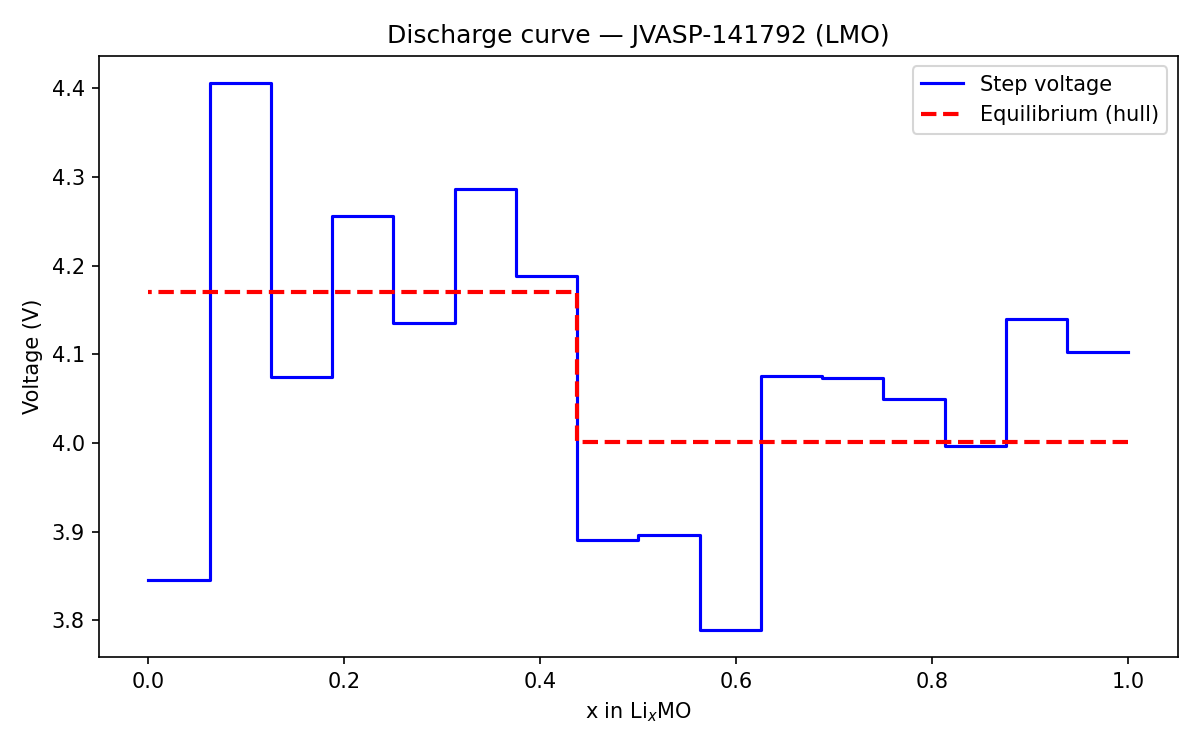

In [ ]:
from IPython.display import Image
# jae's own staircase plot: blue = raw step voltages, red dashed = equilibrium (hull) plateaus.
Image(f"{BASE}/screening_cathode/analysis/discharge_curve_JVASP-141792.png")

## Section C — The `battery_predict` LLM tool (agapi)

`battery_predict` POSTs a POSCAR to `atomgpt.org/battery/predict` and returns a voltage profile + gravimetric/volumetric capacity for Li, Na, K, Mg, Ca, or Zn. It's the same *family* of method as Section B (sequential ion removal scored with ALIGNN-FF), but it runs server-side — the exact server implementation isn't in this repo, so treat it as a related tool rather than a byte-for-byte copy of jae's `screen.py`/`dft_prep.py`.

### C1 — Raw function call

In [ ]:
from agapi.agents.client import AGAPIClient
from agapi.agents.functions import battery_predict

client = AGAPIClient(api_key=API_KEY)
res = battery_predict(LICOO2, element="Li", api_client=client)
print("formula:", res["formula"])
print("gravimetric capacity (mAh/g):", res["gravimetric_capacity"])
print("volumetric capacity (mAh/cm^3):", res["volumetric_capacity"])

formula: LiCoO2
gravimetric capacity (mAh/g): 273.839
volumetric capacity (mAh/cm^3): 1371.762


In [ ]:
v = res["voltages"]
plt.plot(range(1, len(v) + 1), v, "s-", color="crimson")
plt.xlabel("Step"); plt.ylabel("Voltage (V)")
plt.title(f"battery_predict voltage profile — {res['formula']}")
plt.grid(alpha=0.3); plt.show()

### C2 — Natural-language agent chat

The AtomGPT chat agent picks and invokes `battery_predict` on its own from a plain-English question. No separate OpenAI key is needed — the backend hosts the model.

In [ ]:
from agapi.agents import AGAPIAgent

agent = AGAPIAgent(api_key=API_KEY)
ans = agent.query_sync(
    "What is the voltage profile and theoretical capacity of LiCoO2 as a Li-ion cathode?",
    render_html=True,
)

[Iteration 1/15]
  Calling: query_by_formula
[Iteration 2/15]
  Calling: query_by_jid
[Iteration 3/15]
  Calling: battery_predict
[Iteration 4/15]


---
### Chat-integration status — using the fork `redbbean/agapi @ add-battery-predict`

Section A installs **that fork**, which adds the `battery_predict` function (`agapi/agents/functions.py`), its tool schema (`agapi/agents/schema.py`), and wires it into the `AGAPIAgent` tool loop. The cell below confirms, straight from the installed package, that the tool is registered for the chat agent.

This branch is **not yet merged into upstream `atomgptlab/agapi`**, so the public atomgpt.org chat won't expose `battery_predict` until that PR lands.

In [ ]:
# Verify the fork actually exposes battery_predict to the chat agent.
import agapi
from agapi.agents.schema import TOOLS_SCHEMA
from agapi.agents.functions import battery_predict  # the function the agent calls

print("agapi installed at:", agapi.__file__)

tool_names = [t["function"]["name"] for t in TOOLS_SCHEMA]
print("battery_predict in tool schema:", "battery_predict" in tool_names)
print("battery_predict function importable:", callable(battery_predict))

bp = next(t for t in TOOLS_SCHEMA if t["function"]["name"] == "battery_predict")
print("params exposed to the LLM:", list(bp["function"]["parameters"]["properties"]))

agapi installed at: /usr/local/lib/python3.12/dist-packages/agapi/__init__.py
battery_predict in tool schema: True
battery_predict function importable: True
params exposed to the LLM: ['poscar', 'element', 'model']
